In [1]:

!pip install -q pydicom opencv-python-headless albumentations timm scikit-learn \
             matplotlib seaborn torchmetrics tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

In [2]:
import os, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from  pathlib import Path
from  tqdm.notebook import tqdm

import cv2
import pydicom

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from  torch.utils.data import Dataset, DataLoader
import timm

from  sklearn.metrics import (roc_auc_score, classification_report,
                                   roc_curve, confusion_matrix)
from  sklearn.calibration import calibration_curve
from  scipy import stats
import albumentations as A
from  albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')


SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything()


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")


ROOT     = Path('/kaggle/input/datasets/organizations/nih-chest-xrays/data')
CSV_PATH = ROOT / 'Data_Entry_2017.csv'
BBOX_CSV = ROOT / 'BBox_List_2017.csv'



IMG_DIRS = sorted(ROOT.glob('images_*'))   
img_lookup = {}
for d in IMG_DIRS:
    for p in d.rglob('*.png'): 
        img_lookup[p.name] = p
print(f"Image folders found : {len(IMG_DIRS)}")
print(f"Total images indexed: {len(img_lookup):,}")


IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 10
LR            = 1e-4
DROPOUT_P    = 0.4
MC_PASSES    = 30
UNCERTAINTY_THRESHOLD = 0.10
FOCAL_GAMMA  = 2.0
FOCAL_ALPHA  = 0.75

print("Config loaded ✔")

Device: cuda | GPU: Tesla P100-PCIE-16GB
Image folders found : 12
Total images indexed: 112,120
Config loaded ✔


**Data Preprocessing**

In [3]:

df = pd.read_csv(CSV_PATH)
print(f"Total records in CSV: {len(df):,}")


all_labels = '|'.join(df['Finding Labels']).split('|')
label_counts = pd.Series(all_labels).value_counts()
print("\nTop finding labels:")
print(label_counts.head(8).to_string())


df_pneumonia = df[df['Finding Labels'].str.contains('Pneumonia', na=False)].copy()
df_normal    = df[df['Finding Labels'] == 'No Finding'].copy()


df_normal_sampled = df_normal.sample(n=len(df_pneumonia) * 3,
                                      random_state=SEED)

df_bin = pd.concat([df_pneumonia, df_normal_sampled]).reset_index(drop=True)
df_bin['label'] = df_bin['Finding Labels'].str.contains(
                        'Pneumonia', na=False).astype(int)


df_bin['filepath'] = df_bin['Image Index'].map(img_lookup).astype(str)


missing = df_bin['filepath'] == 'nan'
if missing.any():
    print(f"Warning: {missing.sum()} images not found — dropping.")
    df_bin = df_bin[~missing].reset_index(drop=True)


train_val_names = set(open(ROOT / 'train_val_list.txt').read().split()) 
test_names      = set(open(ROOT / 'test_list.txt').read().split())

df_trainval = df_bin[df_bin['Image Index'].isin(train_val_names)].reset_index(drop=True)
df_test     = df_bin[df_bin['Image Index'].isin(test_names)].reset_index(drop=True)


from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df_trainval, test_size=0.15,
                                      stratify=df_trainval['label'],
                                      random_state=SEED)

print(f"\nSplit (official lists):")
print(f"  Train : {len(df_train):,}  |  Val : {len(df_val):,}  |  Test : {len(df_test):,}")
print(f"  Pneumonia +ve: {df_bin['label'].sum():,}  |  Normal: {(df_bin['label']==0).sum():,}")
df_bin[['Image Index', 'Finding Labels', 'Patient Age',
        'Patient Gender', 'View Position', 'label', 'filepath']].head(3)

Total records in CSV: 112,120

Top finding labels:
No Finding       60361
Infiltration     19894
Effusion         13317
Atelectasis      11559
Nodule            6331
Mass              5782
Pneumothorax      5302
Consolidation     4667

Split (official lists):
  Train : 3,774  |  Val : 666  |  Test : 1,284
  Pneumonia +ve: 1,431  |  Normal: 4,293


,Image Index,Finding Labels,Patient Age,Patient Gender,View Position,label,filepath
0,00000013_010.png,Effusion|Pneumonia|Pneumothorax,60,M,AP,1,/kaggle/input/datasets/organizations/nih-chest...
1,00000032_012.png,Atelectasis|Consolidation|Edema|Pneumonia,55,F,AP,1,/kaggle/input/datasets/organizations/nih-chest...
2,00000056_000.png,Nodule|Pneumonia,76,M,PA,1,/kaggle/input/datasets/organizations/nih-chest...


Images per folder:
  images_001 : 4,999
  images_002 : 10,000
  images_003 : 10,000
  images_004 : 10,000
  images_005 : 10,000
  images_006 : 10,000
  images_007 : 10,000
  images_008 : 10,000
  images_009 : 10,000
  images_010 : 10,000
  images_011 : 10,000
  images_012 : 7,121

Patient Age — mean: 46.9  std: 16.8  range: 1–414
Patient Gender  — M: 63,340  F: 48,780
View Position   — PA: 67,310  AP: 44,810

View Position in binary subset (Pneumonia + Normal):
View Position
PA    3434
AP    2290

BBox annotations: 984 entries (for 880 unique images)
Labels with bboxes: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']


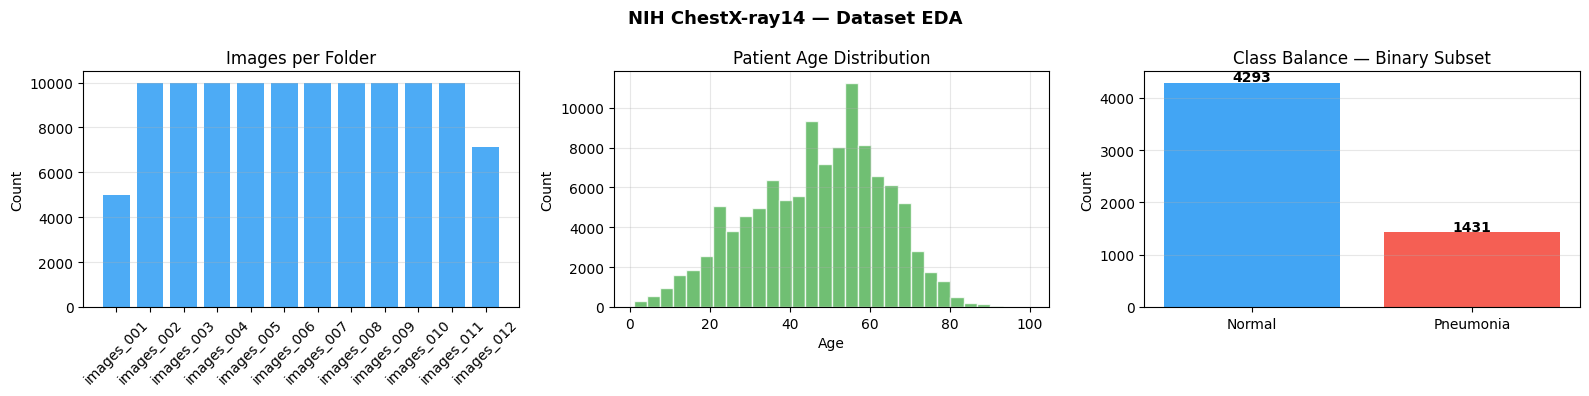

In [4]:

folder_counts = {}
for d in IMG_DIRS:
    folder_counts[d.name] = len(list(d.rglob('*.png')))

print("Images per folder:")
for k, v in sorted(folder_counts.items()):
    print(f"  {k} : {v:,}")


print(f"\nPatient Age — mean: {df['Patient Age'].mean():.1f}  "
      f"std: {df['Patient Age'].std():.1f}  "
      f"range: {df['Patient Age'].min()}–{df['Patient Age'].max()}")
print(f"Patient Gender  — M: {(df['Patient Gender']=='M').sum():,}  "
      f"F: {(df['Patient Gender']=='F').sum():,}")
print(f"View Position   — PA: {(df['View Position']=='PA').sum():,}  "
      f"AP: {(df['View Position']=='AP').sum():,}")


print(f"\nView Position in binary subset (Pneumonia + Normal):")
print(df_bin['View Position'].value_counts().to_string())


bbox_df = pd.read_csv(BBOX_CSV)
print(f"\nBBox annotations: {len(bbox_df):,} entries (for {bbox_df['Image Index'].nunique():,} unique images)")
print("Labels with bboxes:", bbox_df['Finding Label'].unique().tolist())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))


axes[0].bar(list(folder_counts.keys()), list(folder_counts.values()),
            color='#2196F3', alpha=0.8)
axes[0].set_title('Images per Folder'); axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count'); axes[0].grid(axis='y', alpha=0.3)


axes[1].hist(df['Patient Age'].clip(0, 100), bins=30,
             color='#4CAF50', alpha=0.8, edgecolor='white')
axes[1].set_title('Patient Age Distribution')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Count'); axes[1].grid(alpha=0.3)


vc = df_bin['label'].value_counts()
axes[2].bar(['Normal', 'Pneumonia'], [vc[0], vc[1]],
            color=['#2196F3', '#F44336'], alpha=0.85)
axes[2].set_title('Class Balance — Binary Subset')
axes[2].set_ylabel('Count'); axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate([vc[0], vc[1]]):
    axes[2].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.suptitle('NIH ChestX-ray14 — Dataset EDA', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_overview.png', dpi=150)
plt.show()

**CLAHE preprocessing + lung crop helper**

In [5]:
def load_and_preprocess(path: str, img_size: int = 224) -> np.ndarray:
    """
    Load chest X-ray (PNG or DICOM), apply CLAHE contrast enhancement,
    and resize to img_size × img_size.  Returns HWC uint8 RGB array.
    """
    path = str(path)
    if path.endswith('.dcm'):
        ds  = pydicom.dcmread(path)
        img = ds.pixel_array.astype(np.uint16)
        img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
    else:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")


    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)


    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LANCZOS4)


    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img


def lung_crop(img_rgb: np.ndarray) -> np.ndarray:

    gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, th = cv2.threshold(gray, 0, 255,
                           cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL,
                                  cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return img_rgb
    x, y, w, h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    
    pad = int(0.05 * max(w, h))
    x1 = max(x - pad, 0);  y1 = max(y - pad, 0)
    x2 = min(x + w + pad, img_rgb.shape[1])
    y2 = min(y + h + pad, img_rgb.shape[0])
    crop = img_rgb[y1:y2, x1:x2]
    return cv2.resize(crop, (img_rgb.shape[1], img_rgb.shape[0]))


print("Preprocessing functions defined ✔")

Preprocessing functions defined ✔


In [6]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=10, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.4),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


class ChestXrayDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms=None, apply_lung_crop: bool=True):
        self.df              = df.reset_index(drop=True)
        self.transforms      = transforms
        self.apply_lung_crop = apply_lung_crop

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = load_and_preprocess(row['filepath'], IMG_SIZE)
        if self.apply_lung_crop:
            img = lung_crop(img)
        if self.transforms:
            img = self.transforms(image=img)['image']
        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label



train_ds = ChestXrayDataset(df_train, train_transforms)
val_ds   = ChestXrayDataset(df_val,   val_transforms)
test_ds  = ChestXrayDataset(df_test,  val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 118 | Val: 21 | Test: 41


**Focal Loss****

In [7]:
class FocalLoss(nn.Module):
    """
    Focal Loss: FL(p_t) = -α_t (1 - p_t)^γ  log(p_t)
    Addresses class imbalance (only ~5.6 % pneumonia in NIH dataset).
    gamma=2.0, alpha=0.75 per project decisions.
    """
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0,
                 reduction: str = 'mean'):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        p_t     = torch.exp(-ce_loss)
        alpha_t = torch.where(targets == 1,
                               torch.full_like(ce_loss, self.alpha),
                               torch.full_like(ce_loss, 1 - self.alpha))
        focal   = alpha_t * (1 - p_t) ** self.gamma * ce_loss
        if self.reduction == 'mean':  return focal.mean()
        if self.reduction == 'sum':   return focal.sum()
        return focal

criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
print("FocalLoss defined ✔")

FocalLoss defined ✔


**MC-Dropout Model Factory (DenseNet-121 / ResNet-50 / EfficientNet-B3)**

In [8]:
class MCDropoutClassifier(nn.Module):

    def __init__(self, backbone_name: str, num_classes: int = 2,
                 dropout_p: float = 0.4):
        super().__init__()
        self.backbone_name = backbone_name
        self.dropout_p     = dropout_p

        if backbone_name == 'densenet121':
            base    = models.densenet121(weights='IMAGENET1K_V1')
            in_feats= base.classifier.in_features
            base.classifier = nn.Identity()
            self.features   = base

        elif backbone_name == 'resnet50':
            base    = models.resnet50(weights='IMAGENET1K_V2')
            in_feats= base.fc.in_features
            base.fc = nn.Identity()
            self.features = base

        elif backbone_name == 'efficientnet_b3':
            base     = timm.create_model('efficientnet_b3', pretrained=True)
            in_feats = base.classifier.in_features
            base.classifier = nn.Identity()
            self.features   = base

        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")

        
        self.head = nn.Sequential(
            nn.Linear(in_feats, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.features(x)
        if feat.dim() > 2:  
            feat = F.adaptive_avg_pool2d(feat, (1, 1)).flatten(1)
        return self.head(feat)

    def enable_dropout(self):
        
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()



model_names = ['densenet121', 'resnet50', 'efficientnet_b3']
models_dict  = {name: MCDropoutClassifier(name, dropout_p=DROPOUT_P).to(DEVICE)
                for name in model_names}

for name, m in models_dict.items():
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {name:20s}  params: {n_params/1e6:.2f}M")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 175MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 237MB/s]


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

  densenet121           params: 7.54M
  resnet50              params: 24.62M
  efficientnet_b3       params: 11.55M
